In [1]:
%matplotlib inline

In [27]:
# import the python package

import numpy as np 

import pandas as pd
import os

import skimage.io as io 
from skimage import color, exposure, measure
from skimage.transform import resize
from skimage.filters import threshold_otsu
from skimage.morphology import erosion, dilation, remove_small_holes, remove_small_objects, disk
from skimage.segmentation import felzenszwalb

import cv2
from PIL import Image, ImageOps
import matplotlib.pyplot as plt 

from __future__ import print_function, division

import torch
from PIL import Image
from torch.autograd import Variable
from torchvision import datasets, transforms
import os



In [28]:

data_transforms = transforms.Compose([
    transforms.RandomRotation(degrees=(0, 180), expand=True),
    transforms.Resize((64, 64)),
    # transforms.RandomInvert(),
    # transforms.RandomPosterize(bits=2),
    # transforms.RandomSolarize(threshold=192.0),
    # transforms.RandomEqualize(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor()
    ])

def get_key(dct, value):
    return [k for (k, v) in dct.items() if v == value]

In [29]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# find the mapping of folder-to-label
data = datasets.ImageFolder('for_cloud')
mapping = data.class_to_idx

# net_name = 'efficientnet-b0'

# load model
modelft_file = r'model\classify.pth'


# use GPU
model = torch.load(modelft_file).cuda()
model.eval()

EfficientNet(
  (_conv_stem): Conv2dStaticSamePadding(
    3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False
    (static_padding): ZeroPad2d((0, 1, 0, 1))
  )
  (_bn0): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
  (_blocks): ModuleList(
    (0): MBConvBlock(
      (_depthwise_conv): Conv2dStaticSamePadding(
        32, 32, kernel_size=(3, 3), stride=[1, 1], groups=32, bias=False
        (static_padding): ZeroPad2d((1, 1, 1, 1))
      )
      (_bn1): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
      (_se_reduce): Conv2dStaticSamePadding(
        32, 8, kernel_size=(1, 1), stride=(1, 1)
        (static_padding): Identity()
      )
      (_se_expand): Conv2dStaticSamePadding(
        8, 32, kernel_size=(1, 1), stride=(1, 1)
        (static_padding): Identity()
      )
      (_project_conv): Conv2dStaticSamePadding(
        32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False
    

In [30]:
# Functions

# extract the object from the image
def cutout_plant_from_original(img,binary_final_img):

    r=img[:,:,0]*binary_final_img
    g=img[:,:,1]*binary_final_img
    b=img[:,:,2]*binary_final_img
  
    img_temp=np.dstack([r,g,b])
   
    return img_temp

# Apply a specific color map to the image
def gray2color(gray_array, color_map):  
    '''Apply color map to the gray image.'''
    maxi = gray_array.max()
    mini = gray_array.min()
    gray_rescale = np.int_(gray_image * 
                           np.ones(gray_image.shape) / maxi * 255)
    rows, cols = gray_array.shape
    color_array = np.zeros((rows, cols, 3), np.uint8) 

    for i in range(0, rows):
        for j in range(0, cols):
            color_array[i, j] = color_map[gray_rescale[i, j]]  

    #color_image = Image.fromarray(color_array)
    return color_array

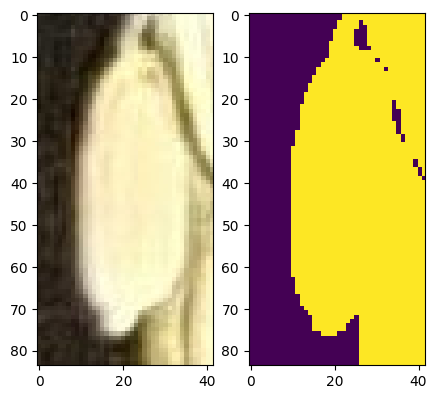

In [31]:
image = io.imread(r'test_image\R103_0_52.jpg')

image_bag_r = image[:, :, 0]

# threshold_otsu segment
thre_bag_r = threshold_otsu(image_bag_r)
grain_mask = image_bag_r > thre_bag_r

grain_mask = remove_small_objects(grain_mask, min_size=100)

fig, ax = plt.subplots(1,2, figsize=(5,5))
ax[0].imshow(image)
ax[1].imshow(grain_mask)

137.83881330309902 5


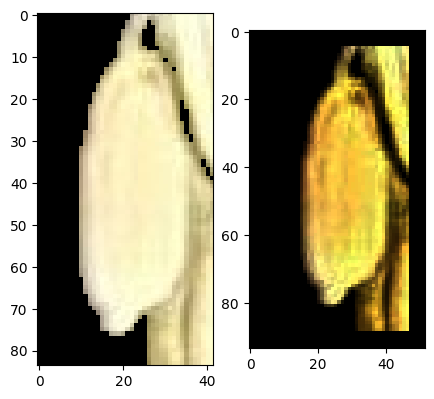

In [32]:
grain_part = cutout_plant_from_original(image, grain_mask)

if grain_part.mean() < 55:
    gam = exposure.adjust_gamma(grain_part, 2)   
    print(grain_part.mean(), 2)

elif 55<=grain_part.mean() < 80:

    gam = exposure.adjust_gamma(grain_part, 3)  
    print(grain_part.mean(), 3)

elif 80 <= grain_part.mean() < 115:

    gam = exposure.adjust_gamma(grain_part, 4)   
    print(grain_part.mean(), 4)

elif grain_part.mean() >= 115:
    gam = exposure.adjust_gamma(grain_part, 5)   
    print(grain_part.mean(), 5)

ret = cv2.copyMakeBorder(gam, 5, 5, 5, 5, cv2.BORDER_CONSTANT, value=(0,0,0))

fig, ax = plt.subplots(1,2,figsize=(5,5))
ax[0].imshow(grain_part)
ax[1].imshow(ret)

range(2, 12, 2)
Processing ratio: 2
['0']
Processing ratio: 4
['0']
Processing ratio: 6
['1']
Processing ratio: 8
['1']
Processing ratio: 10
['1']


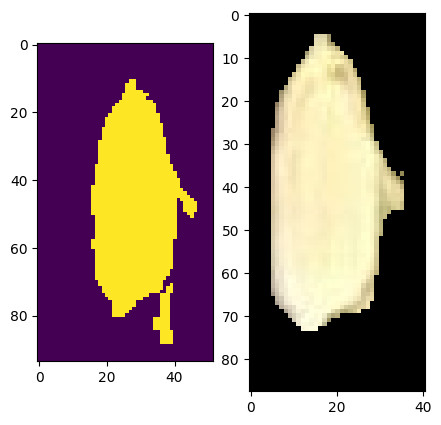

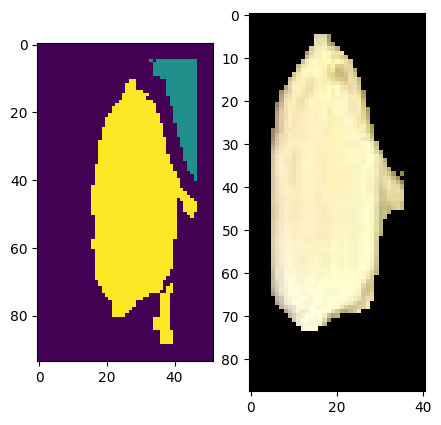

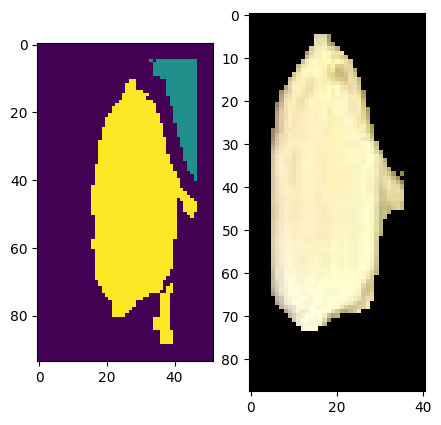

In [ ]:
ret_img = cv2.copyMakeBorder(grain_part, 5, 5, 5, 5, cv2.BORDER_CONSTANT, value=(0,0,0))

image_bag_r = ret[:, :, 0]

# 自适应阈值分割
thre_bag_r = threshold_otsu(image_bag_r)
grain_mask_ret = image_bag_r > thre_bag_r

gray_image = ret[:,:,0] * grain_mask_ret
color_image = cv2.applyColorMap(gray_image, cv2.COLORMAP_JET)
color_image = cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB)

num_dt = pd.DataFrame(columns=['No', 'intact_num'])
ratio_list = range(2,12,2)
print(ratio_list)

stop_outer_loop = False

for n, ratio in enumerate(ratio_list):

    print(f"Processing ratio: {ratio}")
 
    segments_fz = felzenszwalb(color_image, scale=10, sigma=0.05, min_size=int(np.sum(grain_mask_ret>0)/ratio)) 
    grain_props = measure.regionprops_table(segments_fz, color.rgb2gray(ret), 
                                                properties=['bbox', 'image'], cache=True)
    grain_data = pd.DataFrame(grain_props)

    for i in (grain_data.index):
        min_row = grain_data.loc[i,'bbox-0']
        min_col = grain_data.loc[i,'bbox-1']
        max_row = grain_data.loc[i,'bbox-2']
        max_col = grain_data.loc[i,'bbox-3']

        mask_b = resize(grain_data.loc[i,'image'], (max_row-min_row, max_col-min_col))
        
        
        if mask_b.sum()<500:
            continue
        else:

            mask_b = dilation(mask_b, disk(1))
            
            big_grain = (color.gray2rgb(mask_b)*ret_img[min_row:max_row, min_col: max_col]).astype('int') # 原始大图中穗粒
            big_grain = Image.fromarray(big_grain.astype('uint8'), mode='RGB')

            inputs = data_transforms(big_grain)
            inputs.unsqueeze_(0)

            # use GPU
            model = torch.load(modelft_file).cuda()
            model.eval()
            # use GPU
            inputs = Variable(inputs.cuda())

            # forward
            outputs = model(inputs)
            _, preds = torch.max(outputs.data, 1)

            class_name = get_key(mapping, preds.item())
            # use the mapping

            print(class_name)

            if class_name == ['1']:

                mask_b = remove_small_holes(mask_b, area_threshold=5)
                mask_b = erosion(mask_b, disk(3))
                mask_b = dilation(mask_b, disk(3))
                mask_b = remove_small_objects(mask_b, min_size=200)

                mask_b = mask_b.astype('uint8')
                mask_b = cv2.GaussianBlur(mask_b, (0,0), sigmaX=3, sigmaY=3, borderType = cv2.BORDER_DEFAULT)
                mask_b = mask_b.astype(bool)
                
                big_grain = (color.gray2rgb(mask_b)*ret_img[min_row:max_row, min_col: max_col]).astype('int') # 原始大图中穗粒
                big_grain = Image.fromarray(big_grain.astype('uint8'), mode='RGB')
                big_grain = ImageOps.expand(big_grain, border=5, fill=(0, 0, 0))

                fig, ax = plt.subplots(1,2,figsize=(5,5))
                ax[0].imshow(segments_fz)
                ax[1].imshow(big_grain)

                break

